# Laboratorium: Algorytmy ewolucyjne

In [2]:
def fitness(x,y):
    return x**2 + y**2

### Zadanie 1: Reprezentacja i inicjalizacja populacji (1 pkt)
Zgodnie z ideą algorytmów genetycznych, każde rozwiązanie reprezentowane jest przez chromosom, czyli w przypadku ciągłym – wektor parametrów.
* **(1 pkt)** Napisz funkcję `initialize_population(pop_size, dim, bounds)`, która wygeneruje populację początkową składającą się z losowych rozwiązań.
    * `pop_size` to liczba osobników w populacji.
    * `dim` to wymiarowość problemu (długość chromosomu).
    * `bounds` to krotka definiująca zakres poszukiwań, np. **(-10.0, 10.0)**.
    * Zwróć tablicę wektorów wygenerowanych za pomocą rozkładu jednostajnego.

In [3]:
import numpy as np

def initialize_population(pop_size, dim, bounds):
    low, high = bounds
    return np.random.uniform(low, high, size=(pop_size, dim))

### Zadanie 2: Mechanizm selekcji (2 pkt)
Selekcja decyduje, które osobniki będą miały szansę przekazać swoje geny.
* **(2 pkt)** Zaimplementuj funkcję `tournament_selection(population, fitness_scores, k=3)`. Wykorzystaj **selekcję turniejową**, która polega na wylosowaniu niewielkiej grupy osobników (np. **3-5**) i wybraniu z niej najlepszego. Zwróć wybranego osobnika.

In [4]:
import numpy as np

def tournament_selection(population, fitness_scores, k=3):
    indices = np.random.choice(len(population), size=k, replace=False)
    best_idx = indices[np.argmin(fitness_scores[indices])]
    return population[best_idx].copy()

### Zadanie 3: Operatory wariacji – Krzyżowanie i Mutacja (3 pkt)
Ewolucja wymaga tworzenia nowych rozwiązań poprzez krzyżowanie i mutacje. Zaimplementuj operatory genetyczne dla wektorów liczb rzeczywistych.
* **(1.5 pkt) Krzyżowanie:** Napisz funkcję `crossover(parent1, parent2)`. Funkcja powinna wymienić części chromosomów między wybranymi rodzicami.
* **(1.5 pkt) Mutacja:** Napisz funkcję `mutate(individual, mutation_rate, bounds)`. Z niewielkim prawdopodobieństwem algorytm powinien losowo zmienić fragment chromosomu (np. poprzez perturbację liczby rzeczywistej). Pamiętaj o zachowaniu ograniczeń zdefiniowanych w `bounds`.

In [5]:
import numpy as np

def crossover(parent1, parent2):
    alpha = np.random.rand(parent1.shape[0])
    return alpha * parent1 + (1 - alpha) * parent2

def mutate(individual, mutation_rate, bounds):
    low, high = bounds
    ind = individual.copy()
    sigma = 0.1 * (high - low)
    for i in range(len(ind)):
        if np.random.rand() < mutation_rate:
            ind[i] += np.random.normal(0, sigma)
    return np.clip(ind, low, high)

### Zadanie 4: Główna pętla i Elitaryzm (2 pkt)
Połącz wszystkie elementy w działający algorytm oparty na iteracyjnym schemacie ewolucji.
* **(2 pkt)** Napisz funkcję `genetic_algorithm(objective_func, pop_size, dim, bounds, generations)`, która realizuje główną pętlę algorytmu.
    * Pętla ma działać przez określoną liczbę pokoleń (np. **100**).
    * W każdej iteracji: oceniaj populację, dokonuj selekcji rodziców, twórz potomstwo przez krzyżowanie i mutację, a następnie buduj nową populację.
    * Algorytm musi zawierać **elitaryzm** – mechanizm kopiujący kilka najlepszych osobników bezpośrednio i bez zmian do następnego pokolenia, aby zapobiec utracie najlepszych rozwiązań na skutek losowych mutacji lub krzyżowania.

In [ ]:
import numpy as np

def genetic_algorithm(objective_func, pop_size, dim, bounds, generations, mutation_rate=0.1, elitism=2):
    population = initialize_population(pop_size, dim, bounds)
    history = []

    for gen in range(generations):
        fitness_scores = np.array([objective_func(*ind) for ind in population])

        best_idx = np.argmin(fitness_scores)
        best_ind = population[best_idx].copy()
        best_score = fitness_scores[best_idx]
        history.append((best_ind, best_score))

        elite_idx = np.argsort(fitness_scores)[:elitism]
        new_population = [population[i].copy() for i in elite_idx]

        while len(new_population) < pop_size:
            p1 = tournament_selection(population, fitness_scores, k=3)
            p2 = tournament_selection(population, fitness_scores, k=3)
            child = crossover(p1, p2)
            child = mutate(child, mutation_rate, bounds)
            new_population.append(child)

        population = np.array(new_population)

    return population, history

### Uruchomienie: Minimalizacja funkcji Rastrigin'a za pomocą GA

Teraz połączmy wszystko razem. Uruchomimy algorytm genetyczny, aby zminimalizować prostą funkcję `fitness(x, y) = x² + y²`.

**Oczekiwane minimum:** (0, 0) z wartością 0.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

POP_SIZE = 30
DIM = 2
BOUNDS = (-10.0, 10.0)
GENERATIONS = 100
MUTATION_RATE = 0.2

population, history = genetic_algorithm(
    objective_func=fitness,
    pop_size=POP_SIZE,
    dim=DIM,
    bounds=BOUNDS,
    generations=GENERATIONS,
    mutation_rate=MUTATION_RATE,
    elitism=2
)

best_individual, best_score = history[-1]
print(f"Najlepsze znalezione rozwiązanie: x={best_individual[0]:.6f}, y={best_individual[1]:.6f}")
print(f"Wartość funkcji: {best_score:.6f}")

Najlepsze znalezione rozwiązanie: x=-0.000000, y=0.000000
Wartość funkcji: 0.000000


### Wizualizacja przebiegu konwergencji

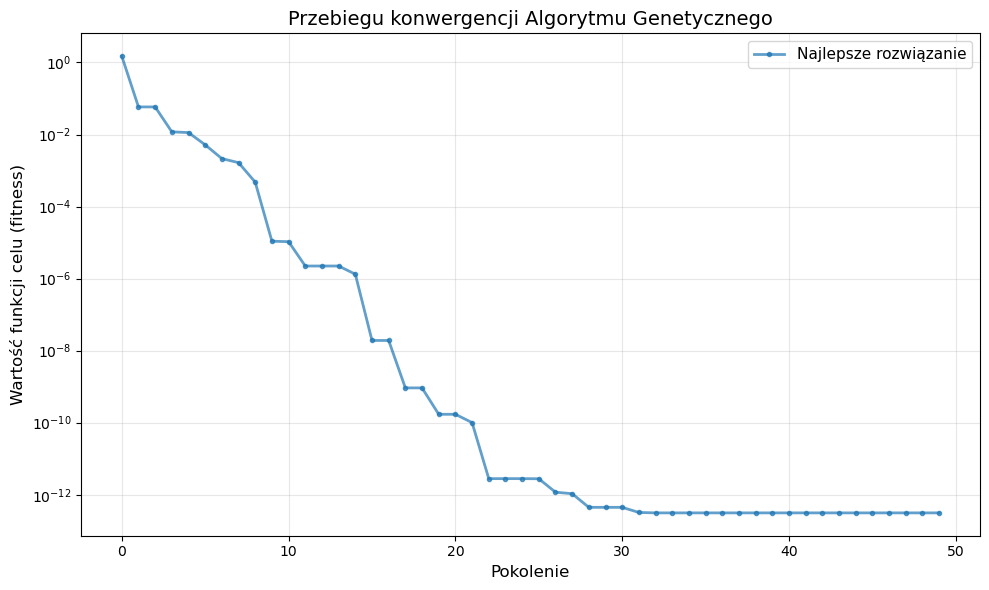

Poprawa fitness: 1.4964 -> 0.000000


In [12]:
# Ekstrakcja historii wartości najlepszych rozwiązań
best_scores = [score for _, score in history]

# Wykres przebiegu
plt.figure(figsize=(10, 6))
plt.plot(best_scores, linewidth=2, marker='o', markersize=3, alpha=0.7, label='Najlepsze rozwiązanie')
plt.xlabel('Pokolenie', fontsize=12)
plt.ylabel('Wartość funkcji celu (fitness)', fontsize=12)
plt.title('Przebiegu konwergencji Algorytmu Genetycznego', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.yscale('log')
plt.tight_layout()
plt.show()

print(f"Poprawa fitness: {best_scores[0]:.4f} -> {best_scores[-1]:.6f}")